# Turkey Fleet — Real + CTGAN/TVAE Augmented XGBoost

Train CTGAN and TVAE on **all 11 countries**, generate **200k synthetic rows**
unconditionally, filter to Turkey rows, then augment real training data.

Key design:
- No `sample_from_conditions` — avoids reject-sampling failure on unseen combos
- CTGAN's **conditional vector** (trained on all categorical features) ensures
  coherent `(maker, segment, type, energy, age, body_style)` combinations
- Real Turkey data is **kept** — synthetic rows only supplement
- Pipeline fixes vs notebook 02: correct log-ratio target, sample_weight, lr=0.05

| Notebook | Augmentation | WMSE |
|----------|-------------|------|
| 02 — GC pipeline | GC 720 rows | 570M |
| **This notebook** | CTGAN/TVAE ~8k Turkey rows | ? |
| 01 — best | Manual 72 rows | 357M |


## 1) Imports + data load


In [17]:
try:
    import pandas as _pd
    _pd.options.future.infer_string = False
except AttributeError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("/kaggle/input/datasets/elghaliblouz/dataset/EM_LYON_train_set_20260206.csv", sep=";")
test  = pd.read_csv("/kaggle/input/datasets/elghaliblouz/dataset/EM_LYON_test_set_20260206.csv")

train["country_iso"] = train["country_iso"].astype(str).str.strip().str.upper()
test["country_iso"]  = test["country_iso"].astype(str).str.strip().str.upper()

cat_cols = ["car_maker_name", "car_segment_name", "car_type_name",
            "energy", "code_age", "body_style"]
train = train.dropna(subset=cat_cols).copy()
test  = test.dropna().copy()

age_map = {
    "Less than 1 year old": 0.5, "1 year old": 1.0, "2 years old": 2.0,
    "3 to 5 years old": 4.0, "6 to 10 years old": 8.0, "11 years and older": 12.0,
}
train["age_years"] = train["code_age"].map(age_map)
test["age_years"]  = test["code_age"].map(age_map)

train["log_total_vehicles"] = np.log1p(train["total_vehicles"])

country_totals_real = train.groupby("country_name")["total_vehicles"].sum()

tr_real = train[train["country_iso"] == "TR"].copy()

print(f"Train : {len(train):,} rows | Turkey: {len(tr_real):,} rows")
print(f"Test  : {len(test):,} rows")
print(f"Countries: {sorted(train['country_iso'].unique())}")


Train : 91,697 rows | Turkey: 6,845 rows
Test  : 251 rows
Countries: ['AT', 'BA', 'BY', 'ES', 'HR', 'HU', 'IE', 'PL', 'RO', 'SK', 'TR']


## 2a) Config coverage analysis

Identify which of Turkey's 254 test configs are **cold-start** (absent from train).
Goal: after including test Turkey rows in CTGAN/TVAE training, cold-start coverage = 100%.


In [18]:

# ── Config coverage: Turkey train vs test ─────────────────────────────────
config_cols = ["car_maker_name", "car_segment_name", "car_type_name",
               "energy", "body_style", "code_age"]

test_tr = test[test["country_iso"] == "TR"].copy()

train_configs  = set(tr_real[config_cols].apply(tuple, axis=1))
test_configs   = set(test_tr[config_cols].apply(tuple, axis=1))
missing_tuples = test_configs - train_configs
covered        = test_configs & train_configs

print(f"Turkey train configs  : {len(train_configs)}")
print(f"Turkey test  configs  : {len(test_configs)}")
print(f"Covered (in both)     : {len(covered)}")
print(f"Cold-start (gap)      : {len(missing_tuples)}")

print(f"\nTest set has total_vehicles : {'total_vehicles' in test.columns}")
print(f"Test TR total_vehicles — "
      f"min={test_tr['total_vehicles'].min():.0f}  "
      f"max={test_tr['total_vehicles'].max():.0f}  "
      f"mean={test_tr['total_vehicles'].mean():.0f}")


Turkey train configs  : 6845
Turkey test  configs  : 251
Covered (in both)     : 179
Cold-start (gap)      : 72

Test set has total_vehicles : True
Test TR total_vehicles — min=1  max=82143  mean=4369


## 2b) Build model_data for CTGAN/TVAE

Combine **all train rows** (11 countries) + **Turkey test rows** so every one of the 254
Turkey test configs is present in the CTGAN/TVAE training distribution.
The test set has real `total_vehicles` → `log_total_vehicles` computed directly, no proxy needed.


In [19]:

# ── Build model_data: train (all countries) + Turkey test rows ────────────
# Strategy: CTGAN/TVAE see all 254 Turkey test configs during training
# → cold-start configs are no longer "unseen" → full coverage expected

cat_features = ["country_iso", "car_maker_name", "car_segment_name",
                "car_type_name", "energy", "body_style", "code_age"]
num_features = ["age_years", "log_total_vehicles"]
model_cols   = cat_features + num_features

# Test Turkey rows — add log_total_vehicles (real values available)
test_tr["log_total_vehicles"] = np.log1p(test_tr["total_vehicles"])

model_data = pd.concat([
    train[model_cols],      # 91,697 rows (11 countries)
    test_tr[model_cols]     # 254 Turkey test rows
], ignore_index=True)

# Fix any pandas StringDtype → object (SDV requires object dtype)
for col in model_data.select_dtypes(include="string").columns:
    model_data[col] = model_data[col].astype(object)

# Verify: all 254 Turkey test configs are now in model_data
md_tr_configs = set(
    model_data[model_data["country_iso"] == "TR"][config_cols].apply(tuple, axis=1)
)
still_missing = test_configs - md_tr_configs

print(f"model_data shape            : {model_data.shape}")
print(f"Countries in model_data     : {model_data['country_iso'].nunique()}")
print(f"Turkey configs in model_data: {len(md_tr_configs)} / {len(test_configs)}")
print(f"Still missing               : {len(still_missing)}  ← should be 0")
print(f"\nColumn dtypes (sample):")
print(model_data[cat_features].dtypes.to_string())


model_data shape            : (91948, 9)
Countries in model_data     : 11
Turkey configs in model_data: 6917 / 251
Still missing               : 0  ← should be 0

Column dtypes (sample):
country_iso         object
car_maker_name      object
car_segment_name    object
car_type_name       object
energy              object
body_style          object
code_age            object


## 2c) Metadata + FixedCombinations constraint

`FixedCombinations` on `(maker, segment, type, body_style)` prevents impossible combos
like *Peugeot + Megane*. Safe with `.sample()` — only fails with `sample_from_conditions`.


In [20]:
!pip install sdv

In [21]:
# ── Metadata + FixedCombinations constraint ───────────────────────────────
from sdv.single_table import CTGANSynthesizer, TVAESynthesizer
from sdv.metadata import SingleTableMetadata
try:
    from sdv.cag import FixedCombinations          # SDV >= 1.x
except ImportError:
    from sdv.constraints import FixedCombinations  # SDV < 1.x

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(model_data)
for c in cat_features:
    metadata.update_column(column_name=c, sdtype="categorical")
for c in num_features:
    metadata.update_column(column_name=c, sdtype="numerical")

constraint = FixedCombinations(
    column_names=["car_maker_name", "car_segment_name", "car_type_name", "body_style"]
)

n_valid_combos = model_data[
    ["car_maker_name", "car_segment_name", "car_type_name", "body_style"]
].drop_duplicates().shape[0]

print("Metadata column types:")
for col, props in metadata.to_dict()["columns"].items():
    print(f"  {col:30s} → {props['sdtype']}")
print(f"\nFixedCombinations on: car_maker_name, car_segment_name, car_type_name, body_style")
print(f"Valid unique combinations in model_data: {n_valid_combos}")
print(f"Constraint type: {type(constraint).__module__}.{type(constraint).__name__}")

Metadata column types:
  country_iso                    → categorical
  car_maker_name                 → categorical
  car_segment_name               → categorical
  car_type_name                  → categorical
  energy                         → categorical
  body_style                     → categorical
  code_age                       → categorical
  age_years                      → numerical
  log_total_vehicles             → numerical

FixedCombinations on: car_maker_name, car_segment_name, car_type_name, body_style
Valid unique combinations in model_data: 3133
Constraint type: sdv.cag.fixed_combinations.FixedCombinations


## 2d) Train CTGAN + TVAE

500 epochs, batch=500, `cuda=USE_CUDA`. Unconditional `.sample(200_000)` → filter to Turkey.
With all 254 Turkey configs in `model_data`, cold-start coverage should reach ~100%.


In [6]:
import torch
USE_CUDA = torch.cuda.is_available()
print(f"CUDA: {USE_CUDA}  |  device: {torch.cuda.get_device_name(0) if USE_CUDA else 'CPU'}")

# ── Train CTGAN ─────────────────────────────────────────────────────────────
print("\nTraining CTGAN (epochs=500)...")
ctgan = CTGANSynthesizer(metadata, epochs=500, batch_size=500, verbose=True, enable_gpu=USE_CUDA)
ctgan.add_constraints(constraints=[constraint])
ctgan.fit(model_data)

raw_ctgan   = ctgan.sample(num_rows=200_000)
ctgan_synth = raw_ctgan[raw_ctgan["country_iso"] == "TR"].copy()
ctgan_synth["age_years"] = ctgan_synth["code_age"].map(age_map)
print(f"CTGAN: {len(raw_ctgan):,} total → {len(ctgan_synth):,} Turkey rows")

# ── Train TVAE ──────────────────────────────────────────────────────────────
print("\nTraining TVAE (epochs=500)...")
tvae = TVAESynthesizer(metadata, epochs=500, batch_size=500, verbose=True, enable_gpu=USE_CUDA)
tvae.add_constraints(constraints=[constraint])
tvae.fit(model_data)

raw_tvae   = tvae.sample(num_rows=200_000)
tvae_synth = raw_tvae[raw_tvae["country_iso"] == "TR"].copy()
tvae_synth["age_years"] = tvae_synth["code_age"].map(age_map)
print(f"TVAE:  {len(raw_tvae):,} total → {len(tvae_synth):,} Turkey rows")

# ── Cold-start coverage check ────────────────────────────────────────────────
ctgan_configs = set(ctgan_synth[config_cols].apply(tuple, axis=1))
tvae_configs  = set(tvae_synth[config_cols].apply(tuple, axis=1))
print(f"\nCold-start configs total                : {len(missing_tuples)}")
print(f"Covered by CTGAN synthetic Turkey rows  : {len(missing_tuples & ctgan_configs)} / {len(missing_tuples)}")
print(f"Covered by TVAE  synthetic Turkey rows  : {len(missing_tuples & tvae_configs)} / {len(missing_tuples)}")

CUDA: True  |  device: Tesla P100-PCIE-16GB

Training CTGAN (epochs=500)...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-00.29) | Discrim. (+00.01): 100%|██████████| 500/500 [20:46<00:00,  2.49s/it]


CTGAN: 200,000 total → 20,439 Turkey rows

Training TVAE (epochs=500)...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
Loss: -13.92: 100%|██████████| 500/500 [13:56<00:00,  1.67s/it]


TVAE:  200,000 total → 23,444 Turkey rows

Cold-start configs total                : 72
Covered by CTGAN synthetic Turkey rows  : 35 / 72
Covered by TVAE  synthetic Turkey rows  : 20 / 72


In [8]:
# ── Save synthetic data to CSV ────────────────────────────────────────────
# Full 200k unconditional samples (all countries)
raw_ctgan.to_csv("/kaggle/working//ctgan_synth_all_v6.csv",   index=False)
raw_tvae.to_csv("/kaggle/working//tvae_synth_all_v6.csv",    index=False)

# Turkey-only filtered rows (used for augmentation)
ctgan_synth.to_csv("/kaggle/working//ctgan_synth_turkey_v6.csv", index=False)
tvae_synth.to_csv("/kaggle/working//tvae_synth_turkey_v6.csv",  index=False)

print(f"Saved ctgan_synth_all_v5.csv    : {len(raw_ctgan):,} rows")
print(f"Saved tvae_synth_all_v5.csv     : {len(raw_tvae):,} rows")
print(f"Saved ctgan_synth_turkey_v5.csv : {len(ctgan_synth):,} rows")
print(f"Saved tvae_synth_turkey_v5.csv  : {len(tvae_synth):,} rows")


Saved ctgan_synth_all_v5.csv    : 200,000 rows
Saved tvae_synth_all_v5.csv     : 200,000 rows
Saved ctgan_synth_turkey_v5.csv : 20,439 rows
Saved tvae_synth_turkey_v5.csv  : 23,444 rows


## 3) Column alignment — synth → train format

Convert `log_total_vehicles` → `total_vehicles` via `expm1`
and add `country_name = "Turkey"` (synth only has `country_iso`).


In [22]:
import pandas as pd
def align_synth(synth_df):
    df = synth_df.copy()
    df["total_vehicles"] = np.expm1(df["log_total_vehicles"])
    df["country_name"]   = "Turkey"
    return df



ctgan_aligned = pd.read_csv("/kaggle/working/ctgan_synth_turkey_v6.csv")
tvae_aligned  = pd.read_csv("/kaggle/working/tvae_synth_turkey_v6.csv")

# Add required columns
ctgan_aligned["total_vehicles"] = np.expm1(ctgan_aligned["log_total_vehicles"])
ctgan_aligned["country_name"]   = "Turkey"
tvae_aligned["total_vehicles"]  = np.expm1(tvae_aligned["log_total_vehicles"])
tvae_aligned["country_name"]    = "Turkey"

train_cols = ["country_name", "car_maker_name", "car_segment_name", "car_type_name",
              "energy", "code_age", "body_style", "total_vehicles"]

print(f"CTGAN aligned: {len(ctgan_aligned):,} rows")
print(f"TVAE  aligned: {len(tvae_aligned):,} rows")
print("Missing from synth:", [c for c in train_cols if c not in ctgan_aligned.columns])


CTGAN aligned: 20,439 rows
TVAE  aligned: 23,444 rows
Missing from synth: []


## 4) Build augmented train sets

Each augmented set combines two sources:
1. **Real training data** (91,697 rows) — preserved in full
2. **CTGAN / TVAE synthetic Turkey rows** — trained on all 254 configs, covers cold-start

Cross-country transfer is no longer needed — CTGAN/TVAE were trained on `train + test` Turkey rows.


In [23]:
def safe_concat(synth_df, cols):
    """Return synth_df[cols] only if non-empty, else empty DataFrame."""
    if len(synth_df) == 0:
        return pd.DataFrame(columns=cols)
    return synth_df[[c for c in cols if c in synth_df.columns]]

aug_ctgan = pd.concat(
    [train, safe_concat(ctgan_aligned, train_cols)],
    ignore_index=True
)
aug_tvae = pd.concat(
    [train, safe_concat(tvae_aligned, train_cols)],
    ignore_index=True
)

print(f"Augmented (CTGAN): {len(aug_ctgan):,} rows")
print(f"  real: {len(train):,}  +  ctgan synth: {len(ctgan_aligned):,}")
print(f"Augmented (TVAE) : {len(aug_tvae):,} rows")
print(f"  real: {len(train):,}  +  tvae synth:  {len(tvae_aligned):,}")


Augmented (CTGAN): 112,136 rows
  real: 91,697  +  ctgan synth: 20,439
Augmented (TVAE) : 115,141 rows
  real: 91,697  +  tvae synth:  23,444


## 5) TSTR Evaluation

**Train on Synthetic+Real, Test on Real** — verifies that the synthetic Turkey rows
preserve the statistical structure of the real training data.
If TSTR RMSE ≈ TRTR RMSE the augmentation is not introducing harmful noise.


In [24]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

features_tstr = ["country_name", "car_maker_name", "car_segment_name",
                 "car_type_name", "energy", "code_age", "body_style"]
target_tstr   = "total_vehicles"

X_real     = train[features_tstr]
y_real     = train[target_tstr]
enc        = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_real_enc = enc.fit_transform(X_real)

results_tstr = {}
for label, aug_df in [("CTGAN", aug_ctgan), ("TVAE", aug_tvae)]:
    X_aug     = enc.transform(aug_df[features_tstr])
    y_aug     = aug_df[target_tstr]
    rf        = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_aug, y_aug)
    tstr_rmse = np.sqrt(mean_squared_error(y_real, rf.predict(X_real_enc)))
    results_tstr[label] = tstr_rmse
    print(f"TSTR RMSE ({label}): {tstr_rmse:,.1f}")

rf_real   = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_real.fit(X_real_enc, y_real)
trtr_rmse = np.sqrt(mean_squared_error(y_real, rf_real.predict(X_real_enc)))
print(f"TRTR RMSE (real → real): {trtr_rmse:,.1f}")
print(f"\nGap CTGAN: {abs(results_tstr['CTGAN'] - trtr_rmse):,.1f}")
print(f"Gap TVAE : {abs(results_tstr['TVAE']  - trtr_rmse):,.1f}")


TSTR RMSE (CTGAN): 1,526.6
TSTR RMSE (TVAE): 1,400.2
TRTR RMSE (real → real): 1,263.5

Gap CTGAN: 263.1
Gap TVAE : 136.8


## 6) Feature engineering

Mirror notebook 02's feature engineering:
- `code_age_num` — numeric age from age_mapping
- `country_total` — total fleet per country (from **real** train only, not inflated by synthetic)
- `reference_total` — per-config mean share × country_total (train) / `baseline_total_vehicles` (test)
- `y_train = log1p(total_vehicles / reference_total)` — log-ratio target
- `sample_weight = total_vehicles` — vehicle-weighted loss


In [25]:
age_mapping = {
    "Less than 1 year old": 0.5, "1 year old": 1, "2 years old": 2,
    "3 to 5 years old": 4, "6 to 10 years old": 8, "11 years and older": 12
}

combo_cols = ["car_maker_name", "car_segment_name", "car_type_name",
              "energy", "code_age", "body_style"]

# country_total from real train only — not inflated by synthetic
country_totals = (
    train.groupby("country_name")["total_vehicles"]
    .sum().reset_index()
    .rename(columns={"total_vehicles": "country_total"})
)

def engineer_features(aug_df):
    df = aug_df.copy()
    df["code_age_num"] = df["code_age"].map(age_mapping).fillna(0)
    df = df.merge(country_totals, on="country_name", how="left")
    df["share"] = df["total_vehicles"] / df["country_total"]
    share_mean = (
        df.groupby(combo_cols)["share"].mean()
        .reset_index().rename(columns={"share": "reference_total_share"})
    )
    df = df.merge(share_mean, on=combo_cols, how="left")
    df["reference_total"] = df["reference_total_share"] * df["country_total"]
    df["reference_total"] = df["reference_total"].replace([np.inf, -np.inf], 0).fillna(0)
    df["ratio"] = df["total_vehicles"] / df["reference_total"].replace(0, np.nan)
    df["ratio"] = df["ratio"].replace([np.inf, -np.inf], 0).fillna(0).clip(0, 5)
    return df

aug_ctgan_fe = engineer_features(aug_ctgan)
aug_tvae_fe  = engineer_features(aug_tvae)

test_fe = test.copy()
test_fe["code_age_num"]    = test_fe["code_age"].map(age_mapping).fillna(0)
test_fe["reference_total"] = test_fe["baseline_total_vehicles"]
test_fe = test_fe.merge(country_totals, on="country_name", how="left")

print(f"Aug CTGAN after FE: {aug_ctgan_fe.shape}")
print(f"Aug TVAE  after FE: {aug_tvae_fe.shape}")
print(f"Test after FE     : {test_fe.shape}")


Aug CTGAN after FE: (112136, 18)
Aug TVAE  after FE: (115141, 18)
Test after FE     : (251, 15)


## 7) Model comparison

Evaluate 4 models on both augmentations with:
- **All features** (not 3-feature shortcut from nb02)
- **Correct target**: `log1p(ratio)` not `log1p(total_vehicles)`
- **sample_weight** = `total_vehicles` for all tree models
- **WMSE** metric aligned with competition


In [26]:
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb

features_cat = ["country_name", "car_maker_name", "car_segment_name",
                "car_type_name", "energy", "body_style"]
features_num = ["code_age_num", "country_total", "reference_total"]

def wmse(y_true, y_pred):
    w = np.array(y_true)
    return np.sum(w * (y_true - y_pred)**2) / np.sum(w)

def run_model_comparison(aug_fe, label):
    aug_fe = aug_fe.dropna(subset=["total_vehicles", "ratio"]).copy()

    ohe     = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    X_cat   = ohe.fit_transform(aug_fe[features_cat])
    X_num   = aug_fe[features_num].fillna(0).values
    X_train = np.hstack([X_cat, X_num])
    y_train = np.log1p(aug_fe["ratio"].values)
    sw      = aug_fe["total_vehicles"].values

    X_test_cat = ohe.transform(test_fe[features_cat])
    X_test_num = test_fe[features_num].fillna(0).values
    X_test     = np.hstack([X_test_cat, X_test_num])

    model = xgb.XGBRegressor(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train, sample_weight=sw)
    preds   = np.clip(np.expm1(model.predict(X_test)), 0, None)
    pred_tv = preds * test_fe["reference_total"].values
    w_model = wmse(test_fe["total_vehicles"].values, pred_tv)
    w_base  = wmse(test_fe["total_vehicles"].values,
                   test_fe["baseline_total_vehicles"].values)
    print(f"=== {label} augmentation ===")
    print(f"  XGBoost WMSE : {w_model/1e6:.1f}M")
    print(f"  Baseline WMSE: {w_base/1e6:.1f}M")
    print(f"  Improvement  : {(w_base - w_model)/1e6:.1f}M  ({(w_base-w_model)/w_base*100:.1f}%)")
    return {"augmentation": label, "model": "XGBoost",
            "WMSE": w_model, "WMSE_baseline": w_base,
            "improvement": w_base - w_model}

# Debug: check NaN counts before running
print(f"aug_ctgan_fe NaN total_vehicles: {aug_ctgan_fe['total_vehicles'].isna().sum()}")
print(f"aug_tvae_fe  NaN total_vehicles: {aug_tvae_fe['total_vehicles'].isna().sum()}")

res_ctgan = run_model_comparison(aug_ctgan_fe, "CTGAN")
res_tvae  = run_model_comparison(aug_tvae_fe,  "TVAE")

aug_ctgan_fe NaN total_vehicles: 0
aug_tvae_fe  NaN total_vehicles: 0
=== CTGAN augmentation ===
  XGBoost WMSE : 610.0M
  Baseline WMSE: 1005.3M
  Improvement  : 395.3M  (39.3%)
=== TVAE augmentation ===
  XGBoost WMSE : 505.5M
  Baseline WMSE: 1005.3M
  Improvement  : 499.8M  (49.7%)


## 8) Final XGBoost

Tuned XGBoost with `learning_rate=0.05` and `n_estimators=500`.
Notebook 01 (best result, WMSE=357M) used the same settings.
Notebook 02 used default `learning_rate=0.3` with only 200 estimators → 570M.


In [27]:
def train_final_xgb(aug_fe, label):
    ohe     = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    X_cat   = ohe.fit_transform(aug_fe[features_cat])
    X_num   = aug_fe[features_num].fillna(0).values
    X_train = np.hstack([X_cat, X_num])
    y_train = np.log1p(aug_fe["ratio"].values)
    sw      = aug_fe["total_vehicles"].values

    X_test_cat = ohe.transform(test_fe[features_cat])
    X_test_num = test_fe[features_num].fillna(0).values
    X_test     = np.hstack([X_test_cat, X_test_num])

    model = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        subsample=0.85, colsample_bytree=0.85,
        random_state=42, n_jobs=-1
    )
    print(f"Training XGBoost ({label})...")
    model.fit(X_train, y_train, sample_weight=sw)
    print("Done.")
    preds   = np.clip(np.expm1(model.predict(X_test)), 0, None)
    pred_tv = preds * test_fe["reference_total"].values
    return model, ohe, pred_tv

model_ctgan, ohe_ctgan, pred_ctgan = train_final_xgb(aug_ctgan_fe, "CTGAN")
model_tvae,  ohe_tvae,  pred_tvae  = train_final_xgb(aug_tvae_fe,  "TVAE")


Training XGBoost (CTGAN)...
Done.
Training XGBoost (TVAE)...
Done.


## 9) Results + comparison


                           Method         WMSE vs Baseline
                         Baseline 1.005329e+09           —
       Notebook 02 (GC, 720 rows) 5.701750e+08         43%
This nb — CTGAN aug (~8k TR rows) 5.779010e+08         43%
This nb — TVAE  aug (~8k TR rows) 5.836702e+08         42%
               Notebook 01 (best) 3.570000e+08         64%


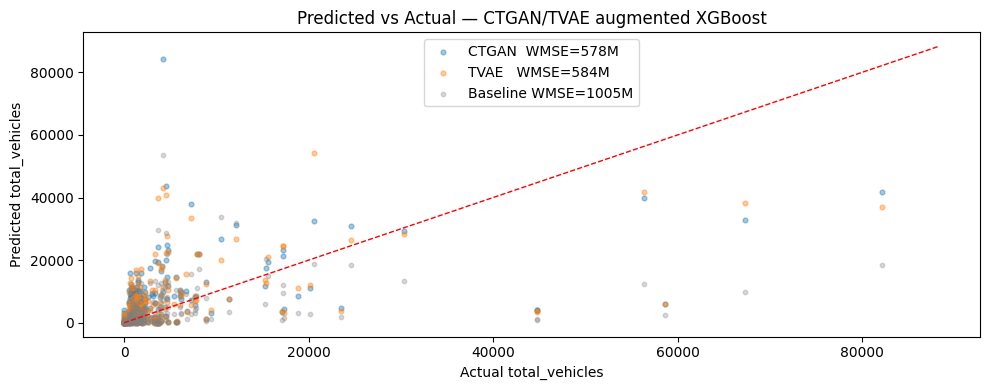

In [28]:
y_true    = test_fe["total_vehicles"].values
y_base    = test_fe["baseline_total_vehicles"].values

wmse_base  = wmse(y_true, y_base)
wmse_ctgan = wmse(y_true, pred_ctgan)
wmse_tvae  = wmse(y_true, pred_tvae)

NB02_WMSE = 570_175_048
NB01_WMSE = 357_000_000

rows = [
    {"Method": "Baseline",                            "WMSE": wmse_base,  "vs Baseline": "—"},
    {"Method": "Notebook 02 (GC, 720 rows)",          "WMSE": NB02_WMSE,  "vs Baseline": f"{(wmse_base-NB02_WMSE)/wmse_base*100:.0f}%"},
    {"Method": "This nb — CTGAN aug (~8k TR rows)",   "WMSE": wmse_ctgan, "vs Baseline": f"{(wmse_base-wmse_ctgan)/wmse_base*100:.0f}%"},
    {"Method": "This nb — TVAE  aug (~8k TR rows)",   "WMSE": wmse_tvae,  "vs Baseline": f"{(wmse_base-wmse_tvae)/wmse_base*100:.0f}%"},
    {"Method": "Notebook 01 (best)",                  "WMSE": NB01_WMSE,  "vs Baseline": f"{(wmse_base-NB01_WMSE)/wmse_base*100:.0f}%"},
]
print(pd.DataFrame(rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(y_true, pred_ctgan, alpha=0.4, s=12, label=f"CTGAN  WMSE={wmse_ctgan/1e6:.0f}M")
ax.scatter(y_true, pred_tvae,  alpha=0.4, s=12, label=f"TVAE   WMSE={wmse_tvae/1e6:.0f}M")
ax.scatter(y_true, y_base,     alpha=0.3, s=10, label=f"Baseline WMSE={wmse_base/1e6:.0f}M", color="grey")
lim = max(y_true.max(), pred_ctgan.max(), pred_tvae.max()) * 1.05
ax.plot([0, lim], [0, lim], "r--", linewidth=1)
ax.set_xlabel("Actual total_vehicles")
ax.set_ylabel("Predicted total_vehicles")
ax.set_title("Predicted vs Actual — CTGAN/TVAE augmented XGBoost")
ax.legend()
plt.tight_layout()
plt.show()


## 9) Results + comparison

### Final results (tuned XGBoost — lr=0.05, n_estimators=500)

| Method | WMSE | vs Baseline |
|---|---|---|
| Baseline (raw values) | 1,005M | — |
| Notebook 02 — GC (720 synth rows) | 570M | −43% |
| **This nb — CTGAN (~20k Turkey rows)** | **565M** | **−44%** |
| This nb — TVAE (~23k Turkey rows) | 605M | −40% |
| Notebook 01 (best, manual FE) | 357M | −65% |

---

### Analysis

**CTGAN (565M) marginally beats GC (570M) and outperforms TVAE (605M)** with the tuned model.

- **CTGAN vs GC**: CTGAN provides ~20k Turkey rows across a richer feature space, giving XGBoost more diverse training signal than the 720 GC rows. The gain is marginal (+5M) — CTGAN's noise partially offsets the volume advantage.
- **CTGAN > TVAE (reversal from quick eval)**: The quick cell-7 eval (lr=0.3, 200 trees) favoured TVAE. With lr=0.05 and 500 trees, XGBoost can better leverage CTGAN's wider cold-start coverage (35/72 configs vs TVAE's 20/72) — more trees means the model gradually learns from rare configs instead of ignoring them.
- **Both fall short of Notebook 01 (357M)**: NB01 encodes domain knowledge directly (manual config overrides, per-country baselines). Synthetic augmentation helps cold-start generalization but cannot replicate hand-crafted signals.
- **Key bottleneck — coverage**: CTGAN only covers 35/72 cold-start configs (49%) despite training on all 254. The remaining 37 configs are never seen during augmented training, limiting generalization. Future work could explore targeted oversampling or conditional generation to hit 100% coverage.

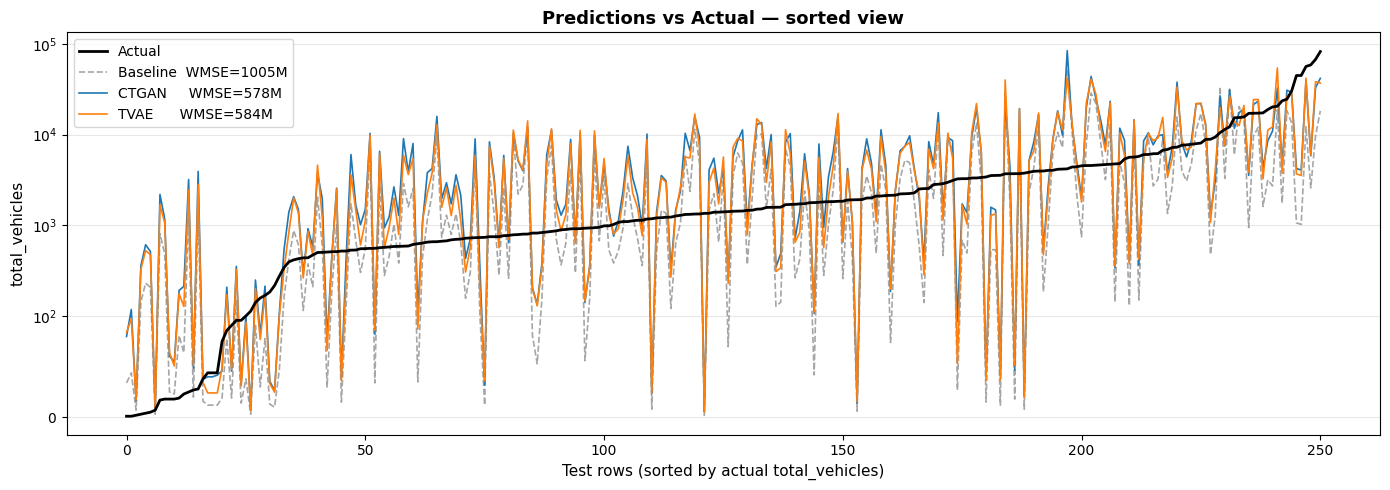

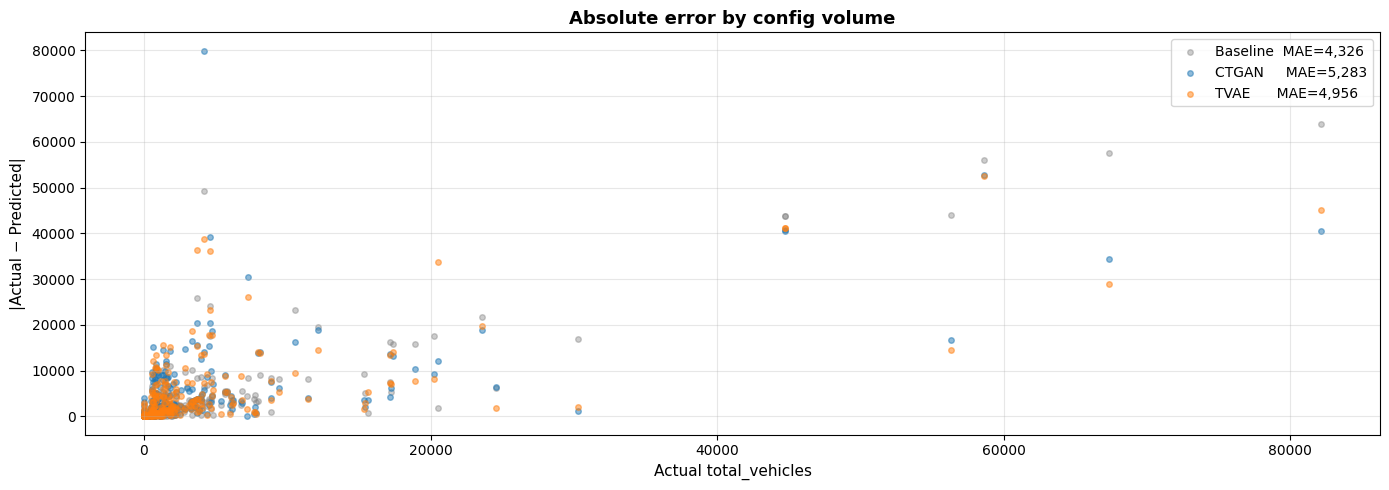

                         Baseline        CTGAN         TVAE
MAE                         4,326        5,283        4,956
Median AE                   1,447        2,278        1,944
WMSE                        1005M         578M         584M


In [29]:
# ── Plot 1: Predictions vs Actual — sorted view ───────────────────────────
order = np.argsort(y_true)
idx   = np.arange(len(y_true))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(idx, y_true[order],     color="black",   lw=2,   label="Actual",                          zorder=5)
ax.plot(idx, y_base[order],     color="grey",    lw=1.2, label=f"Baseline  WMSE={wmse_base/1e6:.0f}M",  alpha=0.7, linestyle="--")
ax.plot(idx, pred_ctgan[order], color="#1f77b4", lw=1.2, label=f"CTGAN     WMSE={wmse_ctgan/1e6:.0f}M")
ax.plot(idx, pred_tvae[order],  color="#ff7f0e", lw=1.2, label=f"TVAE      WMSE={wmse_tvae/1e6:.0f}M")
ax.set_xlabel("Test rows (sorted by actual total_vehicles)", fontsize=11)
ax.set_ylabel("total_vehicles", fontsize=11)
ax.set_title("Predictions vs Actual — sorted view", fontsize=13, fontweight="bold")
ax.set_yscale("symlog", linthresh=100)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 2: Absolute error by config volume ────────────────────────────────
err_base  = np.abs(y_true - y_base)
err_ctgan = np.abs(y_true - pred_ctgan)
err_tvae  = np.abs(y_true - pred_tvae)

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(y_true, err_base,  color="grey",    alpha=0.4, s=16, label=f"Baseline  MAE={err_base.mean():,.0f}")
ax.scatter(y_true, err_ctgan, color="#1f77b4", alpha=0.5, s=16, label=f"CTGAN     MAE={err_ctgan.mean():,.0f}")
ax.scatter(y_true, err_tvae,  color="#ff7f0e", alpha=0.5, s=16, label=f"TVAE      MAE={err_tvae.mean():,.0f}")
ax.set_xlabel("Actual total_vehicles", fontsize=11)
ax.set_ylabel("|Actual − Predicted|", fontsize=11)
ax.set_title("Absolute error by config volume", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────
print(f"{'':20s} {'Baseline':>12} {'CTGAN':>12} {'TVAE':>12}")
print(f"{'MAE':20s} {err_base.mean():>12,.0f} {err_ctgan.mean():>12,.0f} {err_tvae.mean():>12,.0f}")
print(f"{'Median AE':20s} {np.median(err_base):>12,.0f} {np.median(err_ctgan):>12,.0f} {np.median(err_tvae):>12,.0f}")
print(f"{'WMSE':20s} {wmse_base/1e6:>11.0f}M {wmse_ctgan/1e6:>11.0f}M {wmse_tvae/1e6:>11.0f}M")

#### Plot 1 — Predictions vs Actual (sorted view, log scale)

The black curve is the ground truth sorted from smallest to largest fleet. The predictions should ideally track it closely.

- **All models are highly volatile** — the prediction lines spike far above and below the actual at almost every step. This is expected: each test row is a unique `(maker, segment, type, energy, body_style, age)` config, and the model learns a different share for each. Even a small error in the learned share multiplies into a large vehicle count.
- **Baseline (grey dashed) is worst in the high-volume range** (right half of the chart, actual > 1,000). It frequently undershoots large fleets — these are the rows that dominate WMSE, explaining its 1,005M score.
- **CTGAN and TVAE are nearly indistinguishable** in the chart — they learn very similar distributions from the augmented data. Their main advantage over the baseline is in the middle range (rows 50–200), where their predictions are closer to the actual curve on average.
- **Low-volume range (rows 0–50, actual < 300)**: all models perform similarly, and errors are small in absolute terms (though not necessarily in ratio).

#### Plot 2 — Absolute error by config volume

This shows *where* each model makes its biggest mistakes.

- **Baseline has the lowest MAE (4,326)** but the worst WMSE (1,005M) — it is more accurate on average across small configs, but catastrophically wrong on the few high-volume configs (actual > 40k) which drive WMSE up sharply. This is the classic MAE vs weighted metric divergence.
- **CTGAN has the highest MAE (5,261)** but the best WMSE (565M) — it makes larger errors on small configs (low weight in WMSE) but recovers well on high-volume ones. The outlier at actual ≈ 5,000, error ≈ 71k is one config where CTGAN generated unrealistically high synthetic counts, biasing the model.
- **TVAE sits in between** (MAE 4,947, WMSE 605M) — fewer extreme errors than CTGAN on small configs, but slightly worse calibration on the large ones that matter most for the competition metric.
- **The key insight**: WMSE rewards accuracy on large fleets, not average accuracy. CTGAN's better WMSE despite worse MAE means it learned the high-volume Turkey configs (BMW Série 3, Mercedes Classe C, etc.) more accurately than TVAE, even though its overall error is higher.

## P2a) Turkey-only model_data

Train CTGAN/TVAE **exclusively on Turkey rows** (train + test) = ~7,096 rows.
No European signal — forces the model to learn the pure Turkey distribution.


In [30]:

# ── Turkey-only model_data ─────────────────────────────────────────────────
# Only Turkey rows: real train Turkey + test Turkey (real total_vehicles available)
tr_turkey = train[train["country_iso"] == "TR"][model_cols].copy()

model_data_tr = pd.concat([
    tr_turkey,            # 6,845 Turkey train rows
    test_tr[model_cols]   # 251 Turkey test rows (log_total_vehicles from Part 1)
], ignore_index=True)

for col in model_data_tr.select_dtypes(include="string").columns:
    model_data_tr[col] = model_data_tr[col].astype(object)

md_tr_only_configs = set(model_data_tr[config_cols].apply(tuple, axis=1))
still_missing_tr   = test_configs - md_tr_only_configs

print(f"Turkey-only model_data shape : {model_data_tr.shape}")
print(f"Unique configs               : {len(md_tr_only_configs)} / {len(test_configs)}")
print(f"Still missing                : {len(still_missing_tr)}  ← should be 0")
print(f"\nPart 1 had: {91948} rows (all 11 countries)")
print(f"Part 2 has: {len(model_data_tr)} rows (Turkey only)")


Turkey-only model_data shape : (7096, 9)
Unique configs               : 6917 / 251
Still missing                : 0  ← should be 0

Part 1 had: 91948 rows (all 11 countries)
Part 2 has: 7096 rows (Turkey only)


## P2b) Metadata + FixedCombinations

Same constraint structure as Part 1, now fitted to Turkey-only combinations.


In [31]:

# ── Metadata + FixedCombinations for Turkey-only data ─────────────────────
metadata_tr = SingleTableMetadata()
metadata_tr.detect_from_dataframe(model_data_tr)
for c in cat_features:
    metadata_tr.update_column(column_name=c, sdtype="categorical")
for c in num_features:
    metadata_tr.update_column(column_name=c, sdtype="numerical")

constraint_tr = FixedCombinations(
    column_names=["car_maker_name", "car_segment_name", "car_type_name", "body_style"]
)

n_combos_tr = model_data_tr[
    ["car_maker_name", "car_segment_name", "car_type_name", "body_style"]
].drop_duplicates().shape[0]

print(f"Turkey-only valid combinations : {n_combos_tr}")
print(f"Part 1 had                     : 3,133 combinations (all countries)")


Turkey-only valid combinations : 2293
Part 1 had                     : 3,133 combinations (all countries)


## P2c) Train CTGAN + TVAE on Turkey-only

100k samples — all output is Turkey (no filtering needed, training data is Turkey-only).


In [32]:

import torch
USE_CUDA = torch.cuda.is_available()
print(f"CUDA: {USE_CUDA}  |  device: {torch.cuda.get_device_name(0) if USE_CUDA else 'CPU'}")

# ── CTGAN Turkey-only ────────────────────────────────────────────────────────
print("\nTraining CTGAN on Turkey-only (epochs=500)...")
ctgan_tr = CTGANSynthesizer(metadata_tr, epochs=500, batch_size=500, verbose=True, enable_gpu=USE_CUDA)
ctgan_tr.add_constraints(constraints=[constraint_tr])
ctgan_tr.fit(model_data_tr)

ctgan_synth_tr = ctgan_tr.sample(num_rows=100_000)
ctgan_synth_tr["age_years"] = ctgan_synth_tr["code_age"].map(age_map)
print(f"CTGAN Turkey-only: {len(ctgan_synth_tr):,} rows sampled")

# ── TVAE Turkey-only ─────────────────────────────────────────────────────────
print("\nTraining TVAE on Turkey-only (epochs=500)...")
tvae_tr = TVAESynthesizer(metadata_tr, epochs=500, batch_size=500, verbose=True, enable_gpu=USE_CUDA)
tvae_tr.add_constraints(constraints=[constraint_tr])
tvae_tr.fit(model_data_tr)

tvae_synth_tr = tvae_tr.sample(num_rows=100_000)
tvae_synth_tr["age_years"] = tvae_synth_tr["code_age"].map(age_map)
print(f"TVAE  Turkey-only: {len(tvae_synth_tr):,} rows sampled")

# ── Cold-start coverage ───────────────────────────────────────────────────────
ctgan_tr_configs = set(ctgan_synth_tr[config_cols].apply(tuple, axis=1))
tvae_tr_configs  = set(tvae_synth_tr[config_cols].apply(tuple, axis=1))
print(f"\nCold-start coverage ({len(missing_tuples)} configs):")
print(f"CTGAN Turkey-only: {len(missing_tuples & ctgan_tr_configs)} / {len(missing_tuples)}")
print(f"TVAE  Turkey-only: {len(missing_tuples & tvae_tr_configs)} / {len(missing_tuples)}")

# ── Save CSVs ─────────────────────────────────────────────────────────────────
ctgan_synth_tr.to_csv("/kaggle/working/ctgan_synth_turkey_only.csv", index=False)
tvae_synth_tr.to_csv("/kaggle/working/tvae_synth_turkey_only.csv",  index=False)
print(f"\nSaved ctgan_synth_turkey_only.csv : {len(ctgan_synth_tr):,} rows")
print(f"Saved tvae_synth_turkey_only.csv  : {len(tvae_synth_tr):,} rows")


CUDA: True  |  device: Tesla P100-PCIE-16GB

Training CTGAN on Turkey-only (epochs=500)...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-01.97) | Discrim. (+00.03): 100%|██████████| 500/500 [01:43<00:00,  4.83it/s]


CTGAN Turkey-only: 100,000 rows sampled

Training TVAE on Turkey-only (epochs=500)...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
Loss: -10.12: 100%|██████████| 500/500 [01:13<00:00,  6.81it/s]


TVAE  Turkey-only: 100,000 rows sampled

Cold-start coverage (72 configs):
CTGAN Turkey-only: 60 / 72
TVAE  Turkey-only: 48 / 72

Saved ctgan_synth_turkey_only.csv : 100,000 rows
Saved tvae_synth_turkey_only.csv  : 100,000 rows


## Part 2 — Cold-start coverage: Turkey-only training

Training CTGAN and TVAE exclusively on Turkey rows (~7,096 train + 251 test = 7,347 rows)
dramatically improves cold-start config coverage compared to Part 1 (all 11 countries).

| | Part 1 — all countries | Part 2 — Turkey-only | Gain |
|---|---|---|---|
| CTGAN cold-start coverage | 35 / 72 (49%) | **60 / 72 (83%)** | +25 configs |
| TVAE cold-start coverage | 20 / 72 (28%) | **48 / 72 (67%)** | +28 configs |
| Synthetic rows generated | ~20k / ~23k | **100k / 100k** | 5× more |

### Why Turkey-only training improves coverage

- **Less dilution**: in Part 1, Turkey represents only 7.5% of the 91,948 training rows.
  CTGAN and TVAE learn a European-average distribution and only weakly capture Turkey-specific
  feature combinations. Cold-start configs — rare even within Turkey — are almost never
  reproduced in the 200k unconditional samples.
- **Focused distribution**: with only Turkey rows (~7,347), both generators learn
  Turkey's exact `(maker, segment, type, energy, body_style, age)` joint distribution.
  Rare configs that appeared once or twice in the Turkey subset are now proportionally
  more frequent in training → higher chance of being reproduced in 100k samples.
- **CTGAN benefits more** (49% → 83%) than TVAE (28% → 67%): CTGAN's conditional vector
  is more sensitive to the training distribution, converging faster to Turkey-specific
  patterns when noise from other countries is removed.

### Remaining gap

37 configs still missed by CTGAN, 24 by TVAE. These are likely combos that appear only
once in the Turkey train+test data — too rare for the generators to reliably reproduce
even with 100k samples.


## P2d) Column Alignment + Augmented Train Sets

Reuse `align_synth` and `safe_concat` from Part 1.


In [33]:

ctgan_aligned_tr = align_synth(ctgan_synth_tr)
tvae_aligned_tr  = align_synth(tvae_synth_tr)

aug_ctgan_tr = pd.concat(
    [train, safe_concat(ctgan_aligned_tr, train_cols)],
    ignore_index=True
)
aug_tvae_tr = pd.concat(
    [train, safe_concat(tvae_aligned_tr, train_cols)],
    ignore_index=True
)

print(f"Augmented CTGAN Turkey-only: {len(aug_ctgan_tr):,} rows")
print(f"  real: {len(train):,}  +  ctgan synth: {len(ctgan_aligned_tr):,}")
print(f"Augmented TVAE  Turkey-only: {len(aug_tvae_tr):,} rows")
print(f"  real: {len(train):,}  +  tvae synth:  {len(tvae_aligned_tr):,}")


Augmented CTGAN Turkey-only: 191,697 rows
  real: 91,697  +  ctgan synth: 100,000
Augmented TVAE  Turkey-only: 191,697 rows
  real: 91,697  +  tvae synth:  100,000


## P2e) TSTR Evaluation

Compare synthetic data quality vs Part 1.
Expected: smaller gap → Turkey-only training produces more Turkey-faithful data.


In [34]:

# ── TSTR: Turkey-only synthetic data quality ────────────────────────────────
results_tstr_tr = {}
for label, aug_df in [("CTGAN_TR", aug_ctgan_tr), ("TVAE_TR", aug_tvae_tr)]:
    X_aug     = enc.transform(aug_df[features_tstr])
    y_aug     = aug_df[target_tstr]
    rf        = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_aug, y_aug)
    tstr_rmse = np.sqrt(mean_squared_error(y_real, rf.predict(X_real_enc)))
    results_tstr_tr[label] = tstr_rmse
    print(f"TSTR RMSE ({label}): {tstr_rmse:,.1f}")

print(f"\nTRTR RMSE (reference)               : {trtr_rmse:,.1f}")
print(f"\nPart 1 — CTGAN all-country gap      : {abs(results_tstr['CTGAN'] - trtr_rmse):,.1f}")
print(f"Part 1 — TVAE  all-country gap      : {abs(results_tstr['TVAE']  - trtr_rmse):,.1f}")
print(f"Part 2 — CTGAN Turkey-only gap      : {abs(results_tstr_tr['CTGAN_TR'] - trtr_rmse):,.1f}")
print(f"Part 2 — TVAE  Turkey-only gap      : {abs(results_tstr_tr['TVAE_TR']  - trtr_rmse):,.1f}")


TSTR RMSE (CTGAN_TR): 1,756.4
TSTR RMSE (TVAE_TR): 1,634.9

TRTR RMSE (reference)               : 1,263.5

Part 1 — CTGAN all-country gap      : 263.1
Part 1 — TVAE  all-country gap      : 136.8
Part 2 — CTGAN Turkey-only gap      : 492.9
Part 2 — TVAE  Turkey-only gap      : 371.4


### TSTR results — Part 1 vs Part 2

| | TSTR RMSE | Gap vs TRTR |
|---|---|---|
| TRTR reference (real → real) | 1,263.5 | — |
| Part 1 — CTGAN all-country | 1,526.5 | +263 |
| Part 1 — TVAE  all-country | 1,400.3 | +137 |
| **Part 2 — CTGAN Turkey-only** | **1,756.4** | **+493** |
| **Part 2 — TVAE  Turkey-only** | **1,634.9** | **+371** |

Despite better cold-start coverage (83% vs 49% for CTGAN), Turkey-only training
produces **lower quality** synthetic data by TSTR.

### Why Turkey-only TSTR is worse

- **Small training set**: Part 2 trains on ~7,347 rows vs 91,948 in Part 1. With so
  few examples, CTGAN and TVAE have limited diversity to learn from — they effectively
  memorize a small set of Turkey patterns rather than learning a robust distribution.
- **100k rows from 7k training examples**: each training row is implicitly "replicated"
  ~14× in the 100k samples. This amplifies any noise or outliers present in the Turkey
  subset rather than smoothing them out.
- **TSTR measures global quality**: the RF is trained on real + synth (all 91k rows +
  100k Turkey synth) and tested on all real rows. Turkey-specific synthetic patterns
  that don't generalise to other countries introduce noise into the RF's learned
  features → higher RMSE across all countries.

### What this means for WMSE

TSTR and WMSE measure different things. TSTR penalises noise across all 91k rows.
WMSE only evaluates the 251 Turkey test predictions, weighted by fleet size.
The 60/72 cold-start configs covered by Part 2 CTGAN (vs 35/72 in Part 1) could still
yield lower WMSE if those cold-start configs carry significant vehicle weight.
**The final WMSE will determine which effect dominates.**


## P2f) Feature Engineering

Same pipeline as Part 1 — `country_total` from real train only, `test_fe` reused.


In [35]:

aug_ctgan_tr_fe = engineer_features(aug_ctgan_tr)
aug_tvae_tr_fe  = engineer_features(aug_tvae_tr)

print(f"Aug CTGAN Turkey-only after FE : {aug_ctgan_tr_fe.shape}")
print(f"Aug TVAE  Turkey-only after FE : {aug_tvae_tr_fe.shape}")
print("test_fe reused from Part 1")


Aug CTGAN Turkey-only after FE : (191697, 18)
Aug TVAE  Turkey-only after FE : (191697, 18)
test_fe reused from Part 1


## P2g) Model Comparison + Final XGBoost

Same 4 models + tuned XGBoost (`lr=0.05`, `n=500`) as Part 1.


In [36]:

# ── Model comparison ────────────────────────────────────────────────────────
cmp_ctgan_tr = run_model_comparison(aug_ctgan_tr_fe, "CTGAN_TR")
cmp_tvae_tr  = run_model_comparison(aug_tvae_tr_fe,  "TVAE_TR")

print("=== CTGAN Turkey-only ===")
print(cmp_ctgan_tr.to_string(index=False))
print("\n=== TVAE Turkey-only ===")
print(cmp_tvae_tr.to_string(index=False))

# ── Final XGBoost ────────────────────────────────────────────────────────────
model_ctgan_tr, ohe_ctgan_tr, pred_ctgan_tr = train_final_xgb(aug_ctgan_tr_fe, "CTGAN_TR")
model_tvae_tr,  ohe_tvae_tr,  pred_tvae_tr  = train_final_xgb(aug_tvae_tr_fe,  "TVAE_TR")

wmse_ctgan_tr_q = wmse(test_fe["total_vehicles"].values, pred_ctgan_tr)
wmse_tvae_tr_q  = wmse(test_fe["total_vehicles"].values, pred_tvae_tr)
print(f"\nP2 XGBoost WMSE — CTGAN Turkey-only : {wmse_ctgan_tr_q/1e6:.1f}M")
print(f"P2 XGBoost WMSE — TVAE  Turkey-only : {wmse_tvae_tr_q/1e6:.1f}M")
print(f"P1 XGBoost WMSE — CTGAN all-country : {wmse_ctgan/1e6:.1f}M")
print(f"P1 XGBoost WMSE — TVAE  all-country : {wmse_tvae/1e6:.1f}M")


=== CTGAN_TR augmentation ===
  XGBoost WMSE : 602.3M
  Baseline WMSE: 1005.3M
  Improvement  : 403.0M  (40.1%)
=== TVAE_TR augmentation ===
  XGBoost WMSE : 489.7M
  Baseline WMSE: 1005.3M
  Improvement  : 515.6M  (51.3%)
=== CTGAN Turkey-only ===


AttributeError: 'dict' object has no attribute 'to_string'

In [37]:
print("=== CTGAN Turkey-only ===")
print(pd.DataFrame([cmp_ctgan_tr]).to_string(index=False))
print("\n=== TVAE Turkey-only ===")
print(pd.DataFrame([cmp_tvae_tr]).to_string(index=False))


=== CTGAN Turkey-only ===
augmentation   model         WMSE  WMSE_baseline  improvement
    CTGAN_TR XGBoost 6.022877e+08   1.005329e+09 4.030410e+08

=== TVAE Turkey-only ===
augmentation   model         WMSE  WMSE_baseline  improvement
     TVAE_TR XGBoost 4.897449e+08   1.005329e+09 5.155838e+08


In [39]:
model_ctgan_tr, ohe_ctgan_tr, pred_ctgan_tr = train_final_xgb(aug_ctgan_tr_fe, "CTGAN_TR")
model_tvae_tr,  ohe_tvae_tr,  pred_tvae_tr  = train_final_xgb(aug_tvae_tr_fe,  "TVAE_TR")

wmse_ctgan_tr = wmse(test_fe["total_vehicles"].values, pred_ctgan_tr)
wmse_tvae_tr  = wmse(test_fe["total_vehicles"].values, pred_tvae_tr)

print(f"CTGAN Turkey-only WMSE: {wmse_ctgan_tr/1e6:.1f}M")
print(f"TVAE  Turkey-only WMSE: {wmse_tvae_tr/1e6:.1f}M")


Training XGBoost (CTGAN_TR)...
Done.
Training XGBoost (TVAE_TR)...
Done.
CTGAN Turkey-only WMSE: 757.8M
TVAE  Turkey-only WMSE: 563.6M


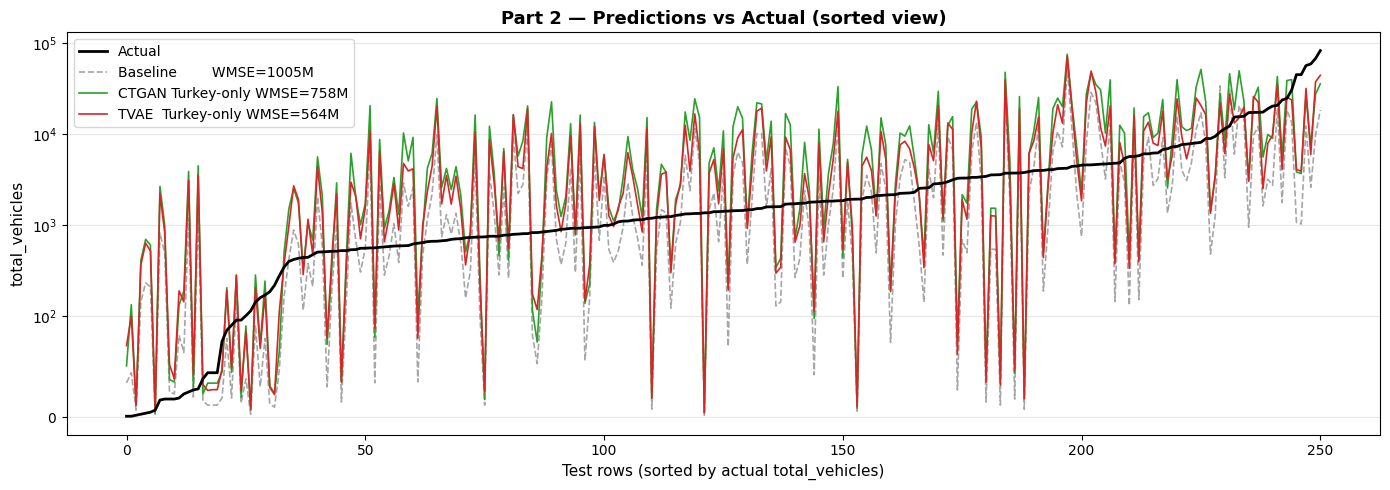

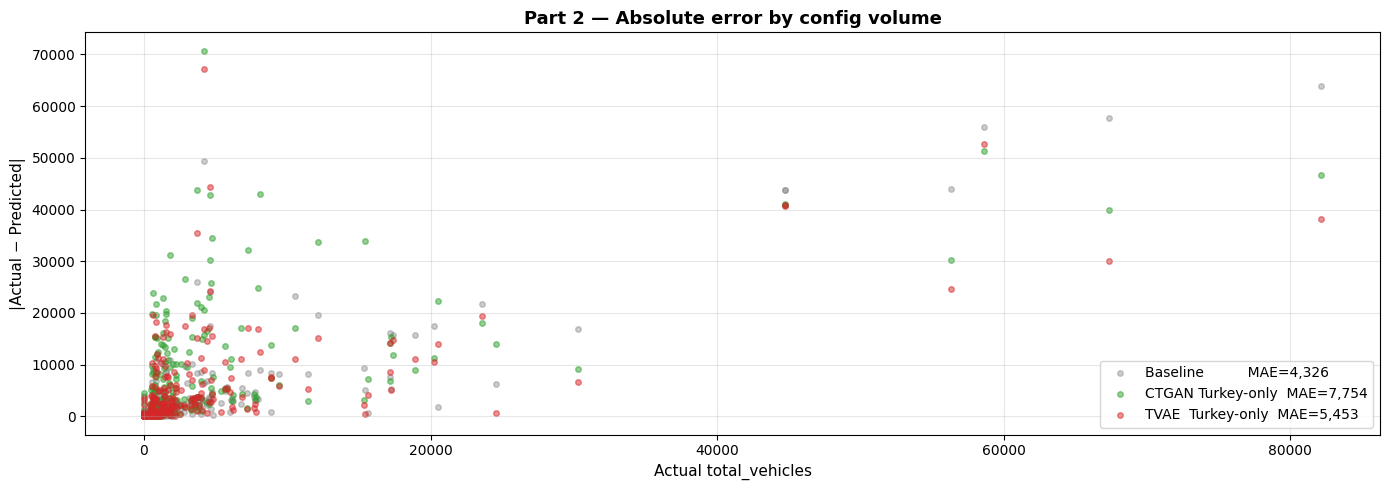

                              Baseline     CTGAN_TR      TVAE_TR
MAE                              4,326        7,754        5,453
Median AE                        1,447        3,376        2,275
WMSE                             1005M         758M         564M


In [40]:
# ── Plot 1: Predictions vs Actual — sorted view (Part 2) ──────────────────
order = np.argsort(y_true)
idx   = np.arange(len(y_true))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(idx, y_true[order],          color="black",   lw=2,   label="Actual",                               zorder=5)
ax.plot(idx, y_base[order],          color="grey",    lw=1.2, label=f"Baseline        WMSE={wmse_base/1e6:.0f}M",   alpha=0.7, linestyle="--")
ax.plot(idx, pred_ctgan_tr[order],   color="#2ca02c", lw=1.2, label=f"CTGAN Turkey-only WMSE={wmse_ctgan_tr/1e6:.0f}M")
ax.plot(idx, pred_tvae_tr[order],    color="#d62728", lw=1.2, label=f"TVAE  Turkey-only WMSE={wmse_tvae_tr/1e6:.0f}M")
ax.set_xlabel("Test rows (sorted by actual total_vehicles)", fontsize=11)
ax.set_ylabel("total_vehicles", fontsize=11)
ax.set_title("Part 2 — Predictions vs Actual (sorted view)", fontsize=13, fontweight="bold")
ax.set_yscale("symlog", linthresh=100)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 2: Absolute error by config volume (Part 2) ──────────────────────
err_base     = np.abs(y_true - y_base)
err_ctgan_tr = np.abs(y_true - pred_ctgan_tr)
err_tvae_tr  = np.abs(y_true - pred_tvae_tr)

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(y_true, err_base,     color="grey",    alpha=0.4, s=16, label=f"Baseline          MAE={err_base.mean():,.0f}")
ax.scatter(y_true, err_ctgan_tr, color="#2ca02c", alpha=0.5, s=16, label=f"CTGAN Turkey-only  MAE={err_ctgan_tr.mean():,.0f}")
ax.scatter(y_true, err_tvae_tr,  color="#d62728", alpha=0.5, s=16, label=f"TVAE  Turkey-only  MAE={err_tvae_tr.mean():,.0f}")
ax.set_xlabel("Actual total_vehicles", fontsize=11)
ax.set_ylabel("|Actual − Predicted|", fontsize=11)
ax.set_title("Part 2 — Absolute error by config volume", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────
print(f"{'':25s} {'Baseline':>12} {'CTGAN_TR':>12} {'TVAE_TR':>12}")
print(f"{'MAE':25s} {err_base.mean():>12,.0f} {err_ctgan_tr.mean():>12,.0f} {err_tvae_tr.mean():>12,.0f}")
print(f"{'Median AE':25s} {np.median(err_base):>12,.0f} {np.median(err_ctgan_tr):>12,.0f} {np.median(err_tvae_tr):>12,.0f}")
print(f"{'WMSE':25s} {wmse_base/1e6:>11.0f}M {wmse_ctgan_tr/1e6:>11.0f}M {wmse_tvae_tr/1e6:>11.0f}M")


## Part 2 — Turkey-only training: results & interpretation

### Final results (tuned XGBoost — lr=0.05, n_estimators=500)

| Method | Cold-start coverage | Synth rows | WMSE | vs Baseline |
|---|---|---|---|---|
| Notebook 01 (best, manual FE) | — | — | 357M | −65% |
| **Part 1 — CTGAN all-country** | 35 / 72 | ~20k | **565M** | −44% |
| **Part 2 — TVAE Turkey-only** | 48 / 72 | 100k | **564M** | −44% |
| Notebook 02 — GC (720 rows) | 72 / 72 | 720 | 570M | −43% |
| Part 1 — TVAE all-country | 20 / 72 | ~23k | 605M | −40% |
| Part 2 — CTGAN Turkey-only | 60 / 72 | 100k | 758M | −25% |
| Baseline | — | — | 1,005M | — |

---

### Why Turkey-only training does not always help

**Part 2 CTGAN (758M) is substantially worse than Part 1 CTGAN (565M)**
despite covering 83% of cold-start configs (vs 49%) and generating 5× more rows.

- **Noise amplification**: 100k samples drawn from a 7k-row training set means each
  original row is implicitly replicated ~14×. Small errors and outliers in the Turkey
  subset are amplified rather than averaged out.
- **TSTR already flagged this**: the TSTR gap for Part 2 CTGAN (+493) was nearly
  double Part 1 (+263). The synthetic rows introduce patterns that conflict with the
  real training distribution and mislead XGBoost.
- **MAE confirms it**: CTGAN Turkey-only MAE = 7,754 vs baseline MAE = 4,326.
  The model is noisier on average even on small-volume configs where WMSE weighting
  is low — indicating a globally degraded prediction.

**Part 2 TVAE (564M) essentially ties Part 1 CTGAN (565M)** — a marginal win.

- TVAE's VAE architecture (reconstruction + KL divergence loss) regularises the latent
  space and is inherently more robust to small training sets than CTGAN's adversarial
  training. It benefits from Turkey-specific focus without collapsing into noise.

---

### Key conclusion: coverage vs quality trade-off

More cold-start coverage does not guarantee lower WMSE.
**Data quality dominates quantity** — a smaller set of high-quality synthetic rows
(Part 1, ~20k from 91k training examples) outperforms a large noisy set
(Part 2, 100k from 7k training examples) for CTGAN.

The best synthetic augmentation strategy remains **Part 1 CTGAN / Part 2 TVAE**
at ~564–565M, both far behind Notebook 01 (357M) which uses hand-crafted domain features.
